# RFEv2 ICPAC Region — Precipitation Visualizer
Daily rainfall (mm/day) clipped to the ICPAC region.

In [4]:
import os
import numpy as np
import netCDF4 as nc
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

RFE_DIR  = r'E:\CGAN\RFE'
SHP_PATH = r'E:\CGAN\Shapefiles\ICPAC_REGIONAL\ICPAC_ADM0.shp'
gdf = gpd.read_file(SHP_PATH)
print(f'Shapefile loaded: {len(gdf)} countries')
print(f'Countries: {list(gdf["COUNTRY"].values)}')

Shapefile loaded: 11 countries
Countries: ['Burundi', 'Djibouti', 'Eritrea', 'Ethiopia', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Sudan', 'Tanzania', 'Uganda']


In [5]:
# ── helpers ──────────────────────────────────────────────────────────────────

def load_rfe(date_str):
    """Load a single day. Returns (lons, lats, data) or None if missing."""
    year = date_str[:4]
    path = os.path.join(RFE_DIR, year, f'{date_str}.nc')
    if not os.path.exists(path):
        return None
    ds = nc.Dataset(path)
    lats = ds.variables['lat'][:]
    lons = ds.variables['lon'][:]
    data = np.array(ds.variables['precipitation'][:])
    ds.close()
    data = np.where(data < 0, np.nan, data)
    return lons, lats, data

# Rainfall colormap (white→blue→green→yellow→orange→red)
LEVELS = [0, 0.1, 1, 2, 5, 10, 20, 30, 40, 60, 100]
COLORS = ['#ffffff','#c6e9f5','#84cae0','#3da8d0','#2ecc71',
          '#f1c40f','#e67e22','#e74c3c','#9b2335','#4a0010']
CMAP  = mcolors.ListedColormap(COLORS)
NORM  = BoundaryNorm(LEVELS, ncolors=len(COLORS))

def plot_day(date_str, ax=None, title=None):
    result = load_rfe(date_str)
    if result is None:
        print(f'No data for {date_str}'); return
    lons, lats, data = result
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(lons, lats, data, cmap=CMAP, norm=NORM, shading='auto')
    gdf.boundary.plot(ax=ax, linewidth=0.7, edgecolor='black')
    ax.set_title(title or f'RFEv2 — {date_str[:4]}-{date_str[4:6]}-{date_str[6:]}', fontsize=13)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(lons.min(), lons.max()); ax.set_ylim(lats.min(), lats.max())
    if standalone:
        plt.colorbar(im, ax=ax, label='mm/day', ticks=LEVELS, shrink=0.8)
        plt.tight_layout(); plt.show()
    return im

print('Helpers ready.')

Helpers ready.


## 1 — Single Day Map

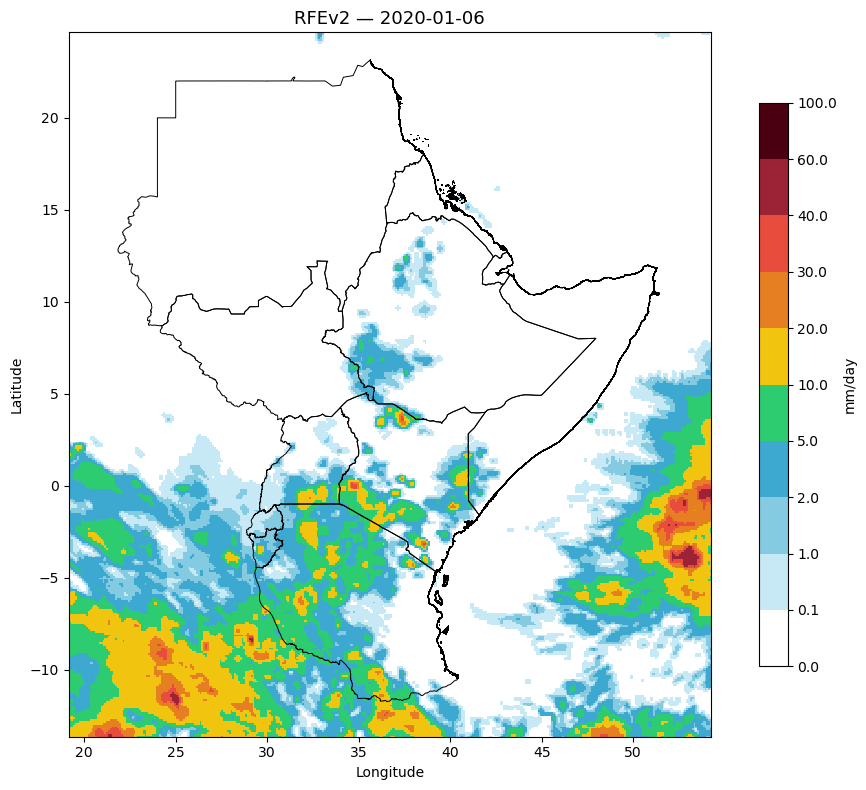

In [9]:
plot_day('20200106')

## 2 — Any Date (change below)

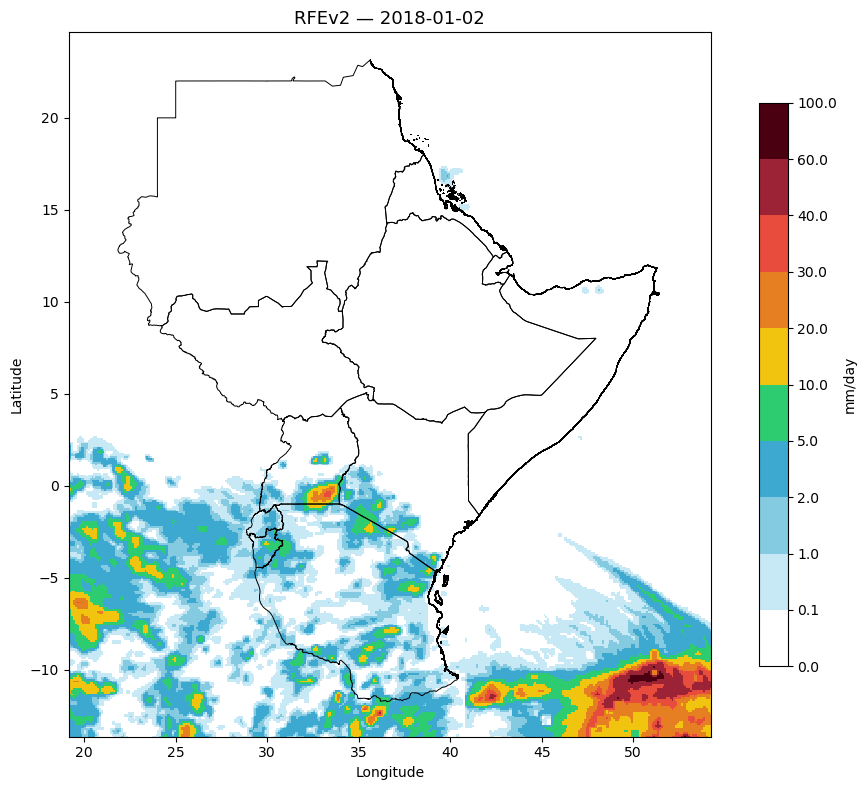

In [6]:
DATE = '20180102'   # ← change to any YYYYMMDD
plot_day(DATE)

## 3 — Multi-Day Grid (one week)

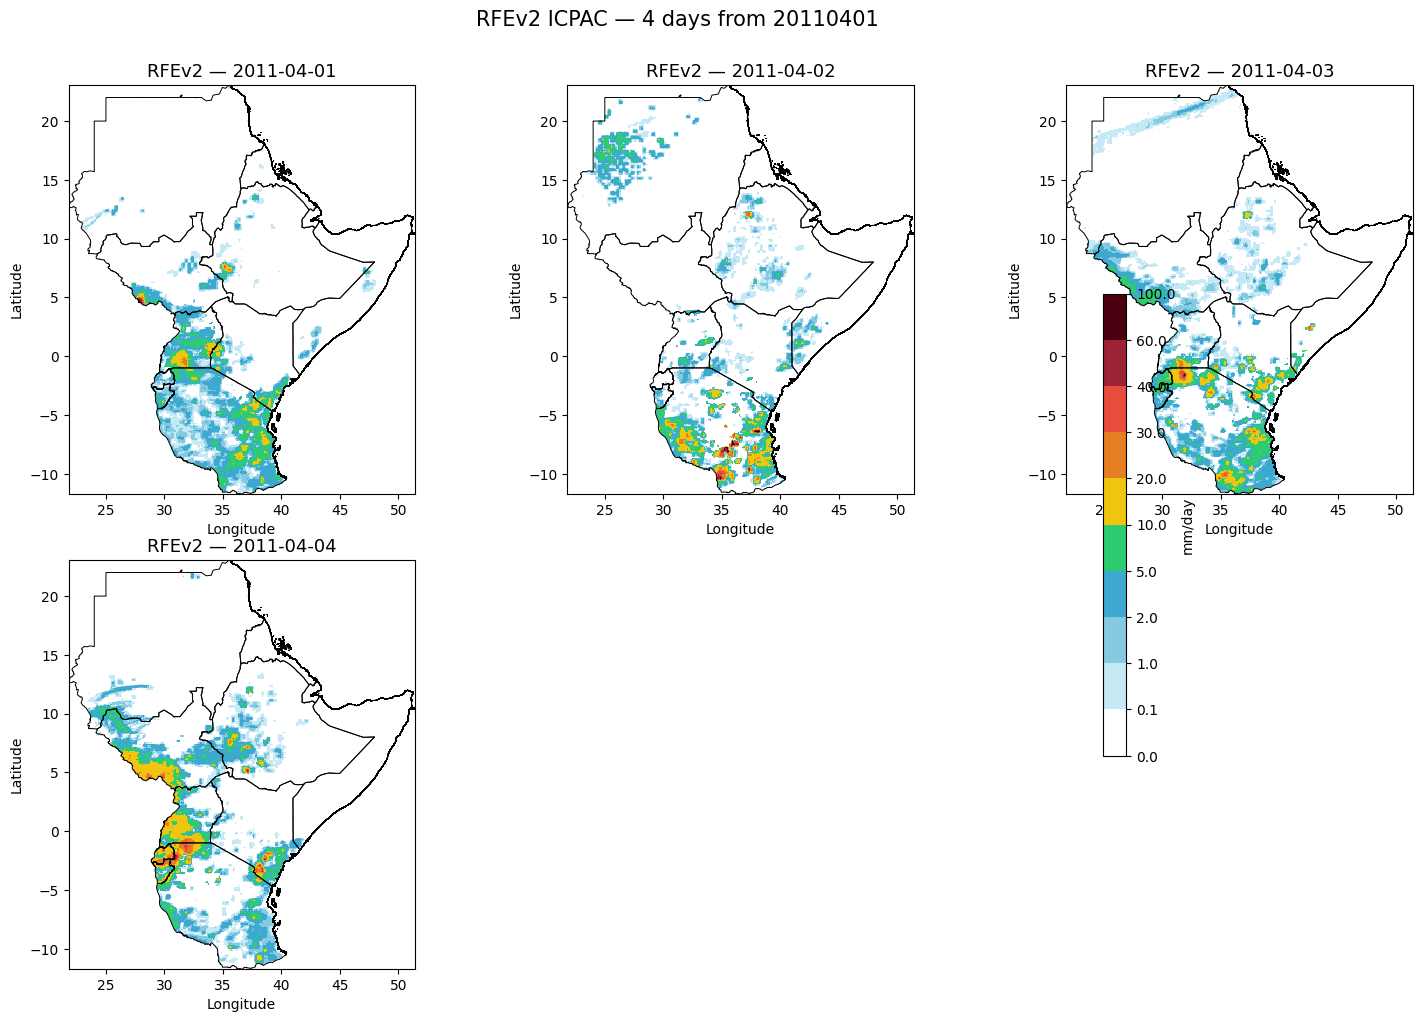

In [11]:
START_DATE = '20110401'   # ← first date
N_DAYS     = 4          # ← how many days to show (max 12)

ncols = 3
nrows = int(np.ceil(N_DAYS / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

d = date(int(START_DATE[:4]), int(START_DATE[4:6]), int(START_DATE[6:]))
ims = []
for i in range(N_DAYS):
    ds = d.strftime('%Y%m%d')
    im = plot_day(ds, ax=axes[i])
    if im: ims.append(im)
    d += timedelta(days=1)

for j in range(N_DAYS, len(axes)):
    axes[j].set_visible(False)

if ims:
    fig.colorbar(ims[0], ax=axes[:N_DAYS], label='mm/day',
                 ticks=LEVELS, shrink=0.6, pad=0.02)
plt.suptitle(f'RFEv2 ICPAC — {N_DAYS} days from {START_DATE}', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 4 — Monthly Mean Map

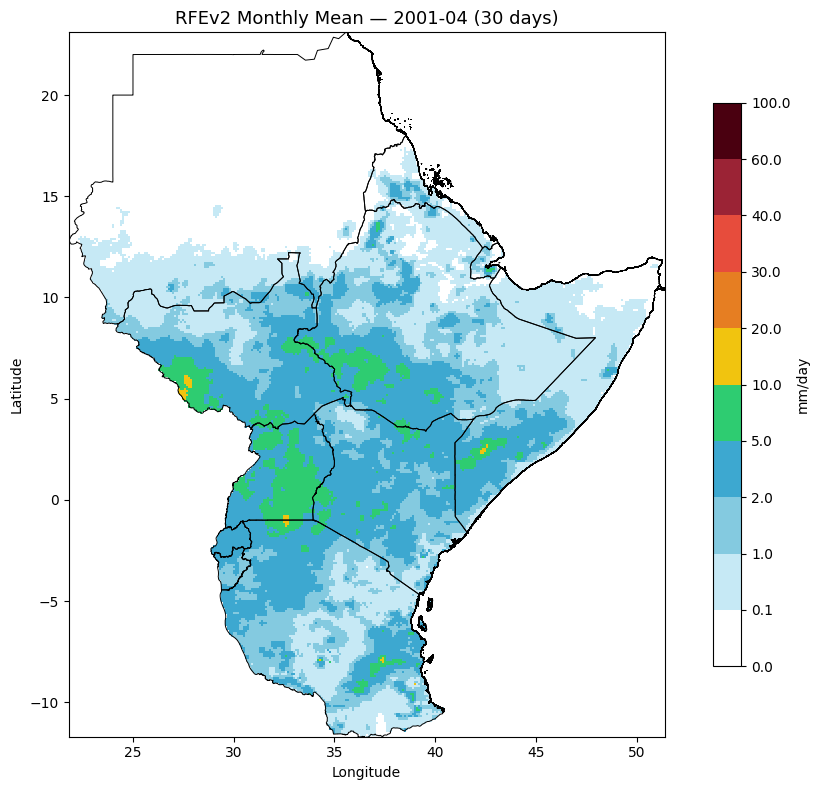

Mean: 1.50 mm/day | Max: 15.60 mm/day


In [12]:
YEAR  = 2001   # ← change year
MONTH = 4      # ← change month

from calendar import monthrange
_, ndays = monthrange(YEAR, MONTH)
stack = []
for day in range(1, ndays + 1):
    ds = f'{YEAR}{MONTH:02d}{day:02d}'
    result = load_rfe(ds)
    if result:
        stack.append(result[2])

if stack:
    mean_data = np.nanmean(stack, axis=0)
    lons, lats, _ = load_rfe(f'{YEAR}{MONTH:02d}01')
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(lons, lats, mean_data, cmap=CMAP, norm=NORM, shading='auto')
    gdf.boundary.plot(ax=ax, linewidth=0.7, edgecolor='black')
    ax.set_title(f'RFEv2 Monthly Mean — {YEAR}-{MONTH:02d} ({len(stack)} days)', fontsize=13)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(lons.min(), lons.max()); ax.set_ylim(lats.min(), lats.max())
    plt.colorbar(im, ax=ax, label='mm/day', ticks=LEVELS, shrink=0.8)
    plt.tight_layout(); plt.show()
    print(f'Mean: {np.nanmean(mean_data):.2f} mm/day | Max: {np.nanmax(mean_data):.2f} mm/day')
else:
    print('No data for that month.')

## 5 — Country-Level Statistics

In [13]:
from rasterio.transform import from_bounds
from rasterio.features import geometry_mask

DATE = '20010401'   # ← change date

result = load_rfe(DATE)
if result:
    lons, lats, data = result
    res_lon = float(lons[1] - lons[0])
    res_lat = float(abs(lats[1] - lats[0]))
    transform = from_bounds(float(lons.min()), float(lats.min()),
                            float(lons.max()), float(lats.max()),
                            len(lons), len(lats))

    stats = []
    for _, row in gdf.iterrows():
        msk = geometry_mask([row.geometry], transform=transform,
                            out_shape=data.shape, invert=True)
        vals = data[msk & ~np.isnan(data)]
        if len(vals) > 0:
            stats.append({'Country': row['COUNTRY'],
                          'Mean (mm/day)': round(float(np.nanmean(vals)), 2),
                          'Max (mm/day)':  round(float(np.nanmax(vals)), 2),
                          'Wet pixels (%)': round(float((vals > 0).mean() * 100), 1)})

    import pandas as pd
    df = pd.DataFrame(stats).sort_values('Mean (mm/day)', ascending=False)
    print(f'RFEv2 country stats — {DATE}')
    display(df.reset_index(drop=True))

RFEv2 country stats — 20010401


,Country,Mean (mm/day),Max (mm/day),Wet pixels (%)
0,Rwanda,8.34,40.29,96.6
1,Kenya,6.80,85.75,73.5
2,Tanzania,4.72,36.85,80.1
3,Uganda,3.98,16.88,97.4
4,South Sudan,2.90,41.37,57.5
5,Ethiopia,1.90,44.79,31.6
6,Burundi,1.36,10.24,72.3
7,Sudan,0.19,9.81,8.7
8,Somalia,0.06,26.64,3.3
9,Djibouti,0.00,0.00,0.0


## 6 — Download Progress Summary

Total files downloaded: 9285


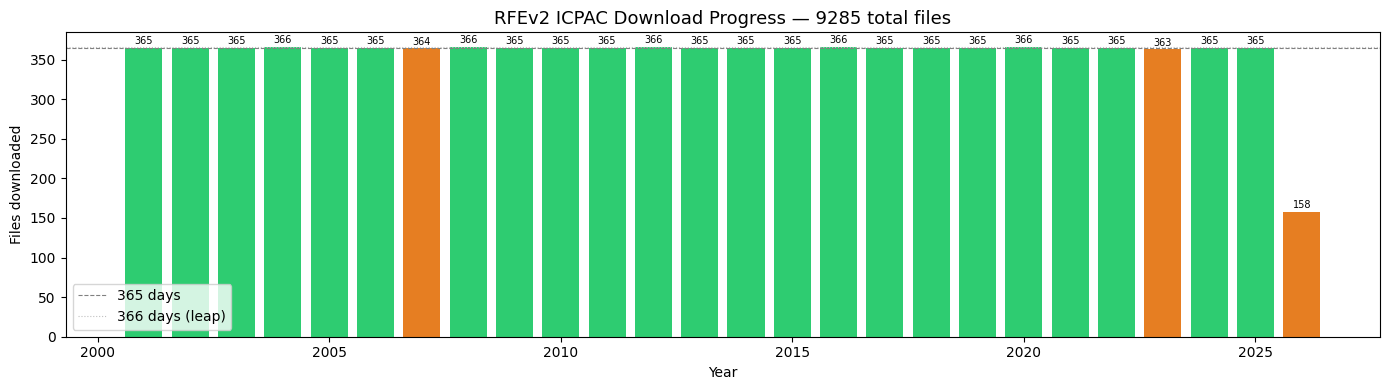

In [3]:
years = sorted([y for y in os.listdir(RFE_DIR) if y.isdigit()])
summary = []
for yr in years:
    files = [f for f in os.listdir(os.path.join(RFE_DIR, yr)) if f.endswith('.nc')]
    summary.append({'Year': int(yr), 'Files': len(files)})

import pandas as pd
df = pd.DataFrame(summary)
total = df['Files'].sum()
print(f'Total files downloaded: {total}')

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(df['Year'], df['Files'],
              color=['#2ecc71' if v >= 365 else '#e67e22' if v > 0 else '#e74c3c' for v in df['Files']])
ax.axhline(365, color='gray', linestyle='--', linewidth=0.8, label='365 days')
ax.axhline(366, color='silver', linestyle=':', linewidth=0.8, label='366 days (leap)')
ax.set_xlabel('Year'); ax.set_ylabel('Files downloaded')
ax.set_title(f'RFEv2 ICPAC Download Progress — {total} total files', fontsize=13)
ax.legend()
for bar, row in zip(bars, summary):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(row['Files']), ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()